### Imports e iniciando cessão com o S3

In [1]:
import pandas as pd 
import boto3 

from dotenv import load_dotenv
from datetime import datetime
from src.data.utils import *

load_dotenv()

True

In [2]:
session = iniciar_cessao_aws()
s3 = session.client("s3")

BUCKET = os.getenv("BUCKET_NAME")


In [21]:
def listar_apenas_pastas(s3_client, bucket: str):
    paginator = s3_client.get_paginator('list_objects_v2')
    todas_pastas = set()

    for page in paginator.paginate(Bucket=bucket):
        for obj in page.get('Contents', []):
            partes = obj['Key'].split('/')
            if len(partes) > 1:
                # Adiciona o caminho da pasta
                pasta = "/".join(partes[:-1])
                todas_pastas.add(pasta)

    print(f"📁 Pastas encontradas em s3://{bucket}/:\n")
    for pasta in sorted(todas_pastas):
        print(f"- {pasta}")

# Executar:
listar_apenas_pastas(s3, BUCKET)


📁 Pastas encontradas em s3://postech-challenge-datascience-003/:

- bronze/ano=2023/dados
- bronze/ano=2023/dicionario
- bronze/ano=2024/dados
- bronze/ano=2024/dicionario
- bronze/ano=2025/dados
- bronze/ano=2025/dicionario
- gold/ano=dimensao/dados
- gold/ano=historico/dados
- gold/dados_externos
- gold/fato/ano=2026/dados
- silver/ano=2023/dados
- silver/ano=2024/dados
- silver/ano=2025/dados
- silver/metadata/ano=2026/dados


In [3]:
prefixo = "gold/dados_externos"

response = s3.list_objects_v2(Bucket=BUCKET,Prefix=prefixo)

if "Contents" in response:
    print(f"Arquivos encontrados em s3://{BUCKET}/{prefixo}:\n")
    for obj in response["Contents"]:
        nome_arquivo = obj['Key'].split('/')[-1]
        nome_arquivo = nome_arquivo.replace(".parquet","")
        tamanho_kb = obj["Size"] / 1024 
        print(f"- {nome_arquivo} ({tamanho_kb:.2f} KB)")
else:
    print(f"Nenhum arquivo encontrado em s3://{BUCKET}/{prefixo}")



Arquivos encontrados em s3://postech-challenge-datascience-003/gold/dados_externos:

-  (0.00 KB)
- dim_contexto_socioeconomico_uf (7.41 KB)
- fact_escola (19476.55 KB)
- fact_municipio (554.39 KB)
- fact_uf_ano (25.89 KB)


## <font color="green">Leitura S3</font>
![Status AWS](https://img.shields.io/badge/AWS-Dados_Carregados-green?style=for-the-badge&logo=amazonaws)


In [4]:
# 1. Tabelas com partição 'ano=historico'
resultado_metas      = carregar_parquet_s3(s3, BUCKET, "RESULTADOS_METAS", ano="historico")
resultado_metas_muni = carregar_parquet_s3(s3, BUCKET, "RESULTADOS_METAS_MUNICIPIO", ano="historico")
df_alunos            = carregar_parquet_s3(s3, BUCKET, "TS_ALUNO", ano="historico")
df_municipios        = carregar_parquet_s3(s3, BUCKET, "TS_MUNICIPIO", ano="historico")
df_estados           = carregar_parquet_s3(s3, BUCKET, "TS_ESTADO", ano="historico")


df_meta              = carregar_parquet_s3(s3, BUCKET, "Fato_Alfabetizacao_Meta", subpasta="fato/ano=2026/dados")
df_alfabetizacao     = carregar_parquet_s3(s3, BUCKET, "FATO_ALFABETIZACAO", subpasta="fato/ano=2026/dados")


df_fact_escola       = carregar_parquet_s3(s3, BUCKET, "fact_escola", subpasta="dados_externos")


Lendo: s3://postech-challenge-datascience-003/gold/ano=historico/dados/RESULTADOS_METAS.parquet
Lendo: s3://postech-challenge-datascience-003/gold/ano=historico/dados/RESULTADOS_METAS_MUNICIPIO.parquet
Lendo: s3://postech-challenge-datascience-003/gold/ano=historico/dados/TS_ALUNO.parquet
Lendo: s3://postech-challenge-datascience-003/gold/ano=historico/dados/TS_MUNICIPIO.parquet
Lendo: s3://postech-challenge-datascience-003/gold/ano=historico/dados/TS_ESTADO.parquet
Lendo: s3://postech-challenge-datascience-003/gold/fato/ano=2026/dados/Fato_Alfabetizacao_Meta.parquet
Lendo: s3://postech-challenge-datascience-003/gold/fato/ano=2026/dados/FATO_ALFABETIZACAO.parquet
Lendo: s3://postech-challenge-datascience-003/gold/dados_externos/fact_escola.parquet


## <font color="green">Enriquecendo a tabela dos Alunos </font>

A analise exploratória e enriquecimento foi feito por todos os integrandes do grupo, em notebooks diferentes

 <font color="#FF9900">Começamos Padronizando a prévia de nomes de colunas de metas </font>

In [5]:
resultado_metas_muni = resultado_metas_muni.rename(columns={'ANO': 'NU_ANO_AVALIACAO'})
resultado_metas = resultado_metas.rename(columns={'ANO': 'NU_ANO_AVALIACAO', 'CD_UF': 'CO_UF'})

# Garantir mesmos tipos numéricos nas chaves
for col in ['NU_ANO_AVALIACAO', 'CO_UF']:
    for df in [df_alunos, df_municipios, df_estados, resultado_metas_muni, resultado_metas]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

if 'CO_MUNICIPIO' in df_alunos.columns and 'CO_MUNICIPIO' in df_municipios.columns:
    df_alunos['CO_MUNICIPIO'] = pd.to_numeric(df_alunos['CO_MUNICIPIO'], errors='coerce')
    df_municipios['CO_MUNICIPIO'] = pd.to_numeric(df_municipios['CO_MUNICIPIO'], errors='coerce')


linhas_iniciais = len(df_alunos)
print(f"Linhas carregadas : {linhas_iniciais}")

Linhas carregadas : 6090791


 <font color="#FF9900"> Então enriqueceremos o TS_ALUNO com dados do MUNICÍPIO (Médias e % Alfabetizados) </font>

In [ ]:
# 1. Filtramos pelo TOTAL GERAL do Município (ID_TIPO_REDE == 5)
cols_muni = ['NU_ANO_AVALIACAO', 'CO_UF', 'CO_MUNICIPIO', 'TP_SERIE', 'VL_MEDIA_LP', 'PC_ALUNO_ALFABETIZADO']

df_muni_total = df_municipios[df_municipios['ID_TIPO_REDE'] == 5][cols_muni].copy()

# 2. Renomeamos para as colunas finais
df_muni_total = df_muni_total.rename(columns={
    'VL_MEDIA_LP': 'VL_MEDIA_LP_TOTAL_MUNICIPIO',
    'PC_ALUNO_ALFABETIZADO': 'PC_ALUNO_ALFABETIZADO_TOTAL_MUNICIPIO'
})

# 3. Se a coluna já existia com nulos no df_alunos, removemos ela antes para recriar limpa
cols_existentes_remover = [c for c in ['VL_MEDIA_LP_TOTAL_MUNICIPIO', 'PC_ALUNO_ALFABETIZADO_TOTAL_MUNICIPIO'] if c in df_alunos.columns]
if cols_existentes_remover:
    df_alunos = df_alunos.drop(columns=cols_existentes_remover)

# 4. Fazemos o Merge perfeito
df_alunos = df_alunos.merge(
    df_muni_total.drop_duplicates(subset=['NU_ANO_AVALIACAO', 'CO_UF', 'CO_MUNICIPIO', 'TP_SERIE']),
    on=['NU_ANO_AVALIACAO', 'CO_UF', 'CO_MUNICIPIO', 'TP_SERIE'],
    how='left'
)

print("✅ Merge concluído com sucesso!")
print("Nulos restantes em VL_MEDIA_LP_TOTAL_MUNICIPIO:", df_alunos['VL_MEDIA_LP_TOTAL_MUNICIPIO'].isna().sum())
print("Percentual de nulos:", f"{df_alunos['VL_MEDIA_LP_TOTAL_MUNICIPIO'].isna().mean():.2%}")


[SUCESSO] Dados de Município agregados!
Colunas agora em df_alunos: ['CO_MUNICIPIO', 'NO_MUNICIPIO', 'VL_MEDIA_LP_TOTAL_MUNICIPIO', 'PC_ALUNO_ALFABETIZADO_TOTAL_MUNICIPIO']


 <font color="#FF9900">Enriquecer TS_ALUNO com dados do ESTADO (UF)</font>

In [ ]:
# 1. Selecionamos as colunas e filtramos pelo TOTAL DO ESTADO (ID_TIPO_REDE == 5)
cols_uf = ['NU_ANO_AVALIACAO', 'CO_UF', 'TP_SERIE', 'VL_MEDIA_LP', 'PC_ALUNO_ALFABETIZADO']

df_estados_total = df_estados[df_estados['ID_TIPO_REDE'] == 5][cols_uf].copy()

# 2. Renomeamos para os nomes finais desejados
df_estados_total = df_estados_total.rename(columns={
    'VL_MEDIA_LP': 'VL_MEDIA_LP_TOTAL_UF',
    'PC_ALUNO_ALFABETIZADO': 'PC_ALUNO_ALFABETIZADO_TOTAL_UF'
})

# 3. Removemos as colunas antigas com nulos do df_alunos antes de recriar
cols_uf_remover = [c for c in ['VL_MEDIA_LP_TOTAL_UF', 'PC_ALUNO_ALFABETIZADO_TOTAL_UF'] if c in df_alunos.columns]
if cols_uf_remover:
    df_alunos = df_alunos.drop(columns=cols_uf_remover)

# 4. Fazemos o Merge perfeito com o Total do Estado
df_alunos = df_alunos.merge(
    df_estados_total.drop_duplicates(subset=['NU_ANO_AVALIACAO', 'CO_UF', 'TP_SERIE']),
    on=['NU_ANO_AVALIACAO', 'CO_UF', 'TP_SERIE'],
    how='left'
)

print("✅ Merge de Estado concluído com sucesso!")
print("Nulos restantes em VL_MEDIA_LP_TOTAL_UF:", df_alunos['VL_MEDIA_LP_TOTAL_UF'].isna().sum())
print("Percentual de nulos:", f"{df_alunos['VL_MEDIA_LP_TOTAL_UF'].isna().mean():.2%}")


[SUCESSO] Dados de Estado agregados!


 <font color="#FF9900">Enriquecer TS_ALUNO com as METAS do MUNICÍPIO</font>

In [8]:
cols_metas_mun = [c for c in ['META_FINAL_2024', 'META_FINAL_2025', 'META_FINAL_2026', 'META_MUN_2024', 'META_MUN_2025', 'META_MUN_2026'] if c in resultado_metas_muni.columns]

if cols_metas_mun:
    renomear_metas_mun = {c: c.replace('META_FINAL_', 'META_MUN_') for c in cols_metas_mun}
    df_metas_mun_prep = resultado_metas_muni[['NU_ANO_AVALIACAO', 'CO_UF', 'CO_MUNICIPIO'] + cols_metas_mun].rename(columns=renomear_metas_mun)
    
    df_alunos = df_alunos.merge(
        df_metas_mun_prep.drop_duplicates(subset=['NU_ANO_AVALIACAO', 'CO_UF', 'CO_MUNICIPIO']),
        on=['NU_ANO_AVALIACAO', 'CO_UF', 'CO_MUNICIPIO'],
        how='left'
    )
    print("[SUCESSO] Metas Municipais agregadas!")


[SUCESSO] Metas Municipais agregadas!


 <font color="#FF9900">Enriquecer TS_ALUNO com as METAS do ESTADO (UF)</font>

In [9]:
cols_metas_uf = [c for c in ['META_FINAL_2024', 'META_FINAL_2025', 'META_FINAL_2026', 'META_UF_2024', 'META_UF_2025', 'META_UF_2026'] if c in resultado_metas.columns]

if cols_metas_uf:
    renomear_metas_uf = {c: c.replace('META_FINAL_', 'META_UF_') for c in cols_metas_uf}
    df_metas_uf_prep = resultado_metas[['NU_ANO_AVALIACAO', 'CO_UF'] + cols_metas_uf].rename(columns=renomear_metas_uf)
    
    df_alunos = df_alunos.merge(
        df_metas_uf_prep.drop_duplicates(subset=['NU_ANO_AVALIACAO', 'CO_UF']),
        on=['NU_ANO_AVALIACAO', 'CO_UF'],
        how='left'
    )
    print("[SUCESSO] Metas Estaduais agregadas!")

# Validação Final

print(f"\nLinhas iniciais: {linhas_iniciais} | Linhas finais: {len(df_alunos)}")
print(f"Colunas finais: {df_alunos.shape[1]}")


[SUCESSO] Metas Estaduais agregadas!

Linhas iniciais: 6090791 | Linhas finais: 6090791
Colunas finais: 40


In [10]:
#Remover duplicados 
df_alunos = df_alunos.drop_duplicates()  
print(f'Duplicados removidos da base :  {linhas_iniciais - len(df_alunos)}')

Duplicados removidos da base :  0


# <font color="green">Analise exploratória de Dados</font>

## MODELOS

In [3]:
import pandas as pd 
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score,accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from sklearn.preprocessing import OneHotEncoder
import matplotlib.pyplot as plt

df_modelo = carregar_parquet_s3(s3_client=s3,bucket=BUCKET,nome_tabela="tabela_modelo",subpasta="modelo")

Lendo: s3://postech-challenge-datascience-003/gold/modelo/tabela_modelo.parquet


In [4]:
def avaliar(nome, y_true, y_pred, y_proba=None):
    print(f"\n=== {nome} ===")
    print(f"Acurácia : {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precisão : {precision_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"Recall   : {recall_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"F1-Score : {f1_score(y_true, y_pred, zero_division=0):.4f}")
    
    # Se você passar as probabilidades, ele também calcula o AUC-ROC:
    if y_proba is not None:
        print(f"AUC-ROC  : {roc_auc_score(y_true, y_proba):.4f}")



def plot_classificacao(model, X_test, y_test, model_name="Modelo"):
    # Previsões de classe (0 ou 1) e de probabilidade (0.0 a 1.0)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))
    
    # ── 1. Matriz de Confusão ──
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm, 
        display_labels=["Não Alfabetizado", "Alfabetizado"]
    )
    disp.plot(ax=ax[0], cmap="Blues", values_format="d")
    ax[0].set_title(f"Matriz de Confusão ({model_name})", fontsize=12, weight="bold")
    
    # ── 2. Curva ROC ──
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    score_auc = auc(fpr, tpr)
    ax[1].plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC (AUC = {score_auc:.4f})")
    ax[1].plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--", label="Aleatório (0.50)")
    ax[1].set_xlabel("Taxa de Falsos Positivos")
    ax[1].set_ylabel("Taxa de Verdadeiros Positivos")
    ax[1].set_title(f"Curva ROC ({model_name})", fontsize=12, weight="bold")
    ax[1].legend(loc="lower right")
    
    plt.tight_layout()
    plt.show()

In [5]:
df_modelo.head(5)

,NU_ANO_AVALIACAO,CO_UF,TP_DEPENDENCIA,IN_PRESENCA_LP,IN_PREENCHIMENTO_LP,IN_ALFABETIZADO,RENDIMENTO_MEDIO_MENSAL_REAIS,RENDA_PERCAPITA_SBENEF_MEDIO,UF_TAXA_FREQ_LIQUIDA_FUND_PCT,ID_ESCOLA,CO_MUNICIPIO
0,2023,11,3.0,0,0,0,2916.0,1524.801152,89.593066,60000001.0,1100205.0
1,2023,11,3.0,1,1,0,2916.0,1524.801152,89.593066,60000001.0,1100205.0
2,2023,11,3.0,0,0,0,2916.0,1524.801152,89.593066,60000001.0,1100205.0
3,2023,11,3.0,1,1,1,2916.0,1524.801152,89.593066,60000001.0,1100205.0
4,2023,11,3.0,0,0,0,2916.0,1524.801152,89.593066,60000001.0,1100205.0


Trabalhando as variaveis de REDE  
a utilização do onehot encoder é util para essas variaveis categoricas com poucas variaveis

In [6]:
#  Mapeamento dos códigos 
mapa_dependencia = {
    1: "Federal",
    2: "Estadual",
    3: "Municipal",
    4: "Privada"
}

df_modelo["REDE"] = df_modelo["TP_DEPENDENCIA"].map(mapa_dependencia)

#Instancia o OneHotEncoder (sparse_output=False já entrega um array normal em vez de matriz esparsa)
cat_encoder = OneHotEncoder(sparse_output=False, dtype=int)
# fit_transform  
rede_1hot = cat_encoder.fit_transform(df_modelo[["REDE"]])

# Transformar as categorias em um dataframe
colunas_nomes = cat_encoder.get_feature_names_out(["REDE"])
df_rede_1hot = pd.DataFrame(rede_1hot, columns=colunas_nomes, index=df_modelo.index)
# agregar as novas tabelas ao dataframe 
df_modelo = pd.concat([df_modelo, df_rede_1hot], axis=1)


print("✅ Colunas criadas pelo OneHotEncoder:")
display(df_modelo[colunas_nomes].head())

✅ Colunas criadas pelo OneHotEncoder:


,REDE_Estadual,REDE_Municipal,REDE_Privada
0,0,1,0
1,0,1,0
2,0,1,0
3,0,1,0
4,0,1,0


Criando as features para a escola

In [7]:
# Indicadores Individuais e de Test-Taking 
df_modelo["IN_AUSENTE"] = (df_modelo["IN_PRESENCA_LP"] == 0).astype("int8")

# Features da Escola (Porte, Absenteísmo, Engajamento)
if "ID_ESCOLA" in df_modelo.columns:
    df_modelo["porte_escola_alunos"] = (
        df_modelo.groupby("ID_ESCOLA")["IN_PRESENCA_LP"].transform("count")
    )
    df_modelo["taxa_absenteismo_escola"] = (
        df_modelo.groupby("ID_ESCOLA")["IN_AUSENTE"].transform("mean")
    )
    df_modelo["taxa_preenchimento_escola"] = (
        df_modelo.groupby("ID_ESCOLA")["IN_PREENCHIMENTO_LP"].transform("mean")
    )




#Normalizando a frequencia escolar da escola
df_modelo["freq_escolar_norm"] = df_modelo["UF_TAXA_FREQ_LIQUIDA_FUND_PCT"] / 100.0


 Features do Município

In [8]:
if "CO_MUNICIPIO" in df_modelo.columns:
    df_modelo["porte_muni_alunos"] = (
        df_modelo.groupby("CO_MUNICIPIO")["IN_PRESENCA_LP"].transform("count")
    )
    df_modelo["taxa_absenteismo_muni"] = (
        df_modelo.groupby("CO_MUNICIPIO")["IN_AUSENTE"].transform("mean")
    )


Features Socioeconômicas Relativas, utilizarei o Z-Score para normalizar os dados, dentro da média e o desvio padrão do ano especifico   

In [9]:
# Instancia o scaler
scaler = StandardScaler()

# fit_transform na coluna de renda 

df_modelo["RENDA_ZSCORE_ANO"] = (
    df_modelo.groupby("NU_ANO_AVALIACAO")["RENDA_PERCAPITA_SBENEF_MEDIO"]
    .transform(lambda x: (x - x.mean()) / x.std())
)

print("Média do Z-score:", df_modelo["RENDA_ZSCORE_ANO"].mean().round(4))  # Fica exatamente 0.0
print("Desvio padrão  :", df_modelo["RENDA_ZSCORE_ANO"].std().round(4))   # Fica exatamente 1.0



Média do Z-score: -0.0
Desvio padrão  : 1.0


In [10]:
mapa_co_uf_regiao = {
    11: "Norte", 12: "Norte", 13: "Norte", 14: "Norte", 15: "Norte", 16: "Norte", 17: "Norte",
    21: "Nordeste", 22: "Nordeste", 23: "Nordeste", 24: "Nordeste", 25: "Nordeste", 26: "Nordeste", 27: "Nordeste", 28: "Nordeste", 29: "Nordeste",
    31: "Sudeste", 32: "Sudeste", 33: "Sudeste", 35: "Sudeste",
    41: "Sul", 42: "Sul", 43: "Sul",
    50: "Centro-Oeste", 51: "Centro-Oeste", 52: "Centro-Oeste", 53: "Centro-Oeste"
}
if "CO_UF" in df_modelo.columns:
    df_modelo["REGIAO"] = df_modelo["CO_UF"].map(mapa_co_uf_regiao)

# One-Hot Encoding da REGIAO
df_regiao_1hot = pd.get_dummies(df_modelo["REGIAO"], prefix="REGIAO", dtype="int8")
df_modelo = pd.concat([df_modelo, df_regiao_1hot], axis=1)

In [11]:
# Normalização Logarítmica nos portes de escola e município
df_modelo["log_porte_escola"] = np.log1p(df_modelo["porte_escola_alunos"])
df_modelo["log_porte_muni"]   = np.log1p(df_modelo["porte_muni_alunos"])


In [12]:
# features que serão selecionadas, ficaremos com as já tratadas e normalizadas 
features = [
    #TARGET
    "IN_ALFABETIZADO" ,
    # Nível Escola
    "taxa_absenteismo_escola",
    "log_porte_escola",
    
    # Nível Município
    "taxa_absenteismo_muni",
    "log_porte_muni",
    
    # Nível Rede (Dummies)
    "REDE_Estadual",
    "REDE_Municipal",
    "REDE_Privada",
    
    # Nível Socioeconômico e Geográfico
    "RENDA_ZSCORE_ANO",
    "freq_escolar_norm",
    
    # Regiões (Dummies)
    "REGIAO_Centro-Oeste",
    "REGIAO_Nordeste",
    "REGIAO_Norte",
    "REGIAO_Sudeste",
    "REGIAO_Sul"
]


In [13]:
df_treino = df_modelo[features].copy()

y = df_treino['IN_ALFABETIZADO']
X = df_treino.drop(columns=['IN_ALFABETIZADO'])

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,   # 20% teste
    random_state=42  # reprodutibilidade
)

In [15]:
# média do treino
media_treino = y_train.mean()
# cria um vetor do mesmo tamanho do y_test
y_baseline = np.full(len(y_test), media_treino)

print(df_treino.shape)
print(X_train.shape)
print(y_train.shape)

In [16]:
from sklearn.linear_model import RidgeCV
import numpy as np

# Testa automaticamente os melhores valores de regularização (alpha)
alphas = np.logspace(-2, 3, 20)  # De 0.01 até 1000

# O RidgeCV encontra o melhor alpha sozinho com validação cruzada (cv=5)
lr_otimizado = RidgeCV(alphas=alphas, cv=5, scoring="r2")
lr_otimizado.fit(X_train, y_train)

print("Melhor parâmetro 'alpha' para o modelo linear:", lr_otimizado.alpha_)

# Predição no teste com o melhor modelo linear
y_pred_lr = lr_otimizado.predict(X_test)


Melhor parâmetro 'alpha' para o modelo linear: 14.38449888287663


In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

# Espaço de busca dos melhores hiperparâmetros
param_dist = {
    'n_estimators': [100, 150, 200],
    'max_depth': [8, 12, 16, 20],
    'min_samples_split': [10, 20, 50],
    'min_samples_leaf': [5, 10, 20],
    'max_features': ['sqrt', 0.7, 0.8]
}

# Base da Random Forest CLASSIFIER usando todos os núcleos da CPU
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

# Busca inteligente em uma amostra de 50 mil linhas para ser rápido
X_sample = X_train.sample(n=min(50000, len(X_train)), random_state=42)
y_sample = y_train.loc[X_sample.index]

random_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=10,               # Testa 10 combinações diferentes
    cv=3,
    scoring='roc_auc',       # ⚠️ MÉTRICA DE CLASSIFICAÇÃO (AUC-ROC em vez de R²)
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print(" Buscando os melhores hiperparâmetros da Random Forest (Classificação)...")
random_search.fit(X_sample, y_sample)

print("Melhores Hiperparâmetros encontrados:")
print(random_search.best_params_)
print(f"Melhor AUC-ROC na validação: {random_search.best_score_:.4f}")

# 4. Treina a Random Forest definitiva com os parâmetros campeões na base completa
rf = RandomForestClassifier(
    **random_search.best_params_, 
    n_jobs=-1, 
    random_state=42
)
rf.fit(X_train, y_train)

# 5. Predição de Classes (0 ou 1) e Probabilidades
y_pred_rf = rf.predict(X_test)
y_pred_proba_rf = rf.predict_proba(X_test)[:, 1]

print(" Random Forest de Classificação treinada com sucesso!")


 Buscando os melhores hiperparâmetros da Random Forest (Classificação)...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Melhores Hiperparâmetros encontrados:
{'n_estimators': 200, 'min_samples_split': 20, 'min_samples_leaf': 20, 'max_features': 'sqrt', 'max_depth': 20}
Melhor AUC-ROC na validação: 0.6501
 Random Forest de Classificação treinada com sucesso!


In [18]:
import lightgbm as lgb
from sklearn.metrics import classification_report, roc_auc_score

# 1. Configuração do LightGBM Classifier
lgbm = lgb.LGBMClassifier(
    n_estimators=500,               # Quantidade de árvores
    learning_rate=0.05,             # Taxa de aprendizado
    num_leaves=31,                  # Principal parâmetro do LightGBM (complexidade da árvore)
    max_depth=6,                    # Evita overfitting
    subsample=0.8,                  # 80% das linhas por árvore
    colsample_bytree=0.8,           # 80% das colunas por árvore
    random_state=42,
    n_jobs=-1                       # Usa todos os núcleos da CPU em paralelo ultra-rápido
)

# Treinamento com Early Stopping
lgbm.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_metric="auc",
    callbacks=[
        lgb.early_stopping(stopping_rounds=15, verbose=True),
        lgb.log_evaluation(period=50)
    ]
)

# Predições
y_pred_lgbm = lgbm.predict(X_test)
y_pred_proba_lgbm = lgbm.predict_proba(X_test)[:, 1]

print(" Treino concluido")
print(f"Melhor iteração: {lgbm.best_iteration_}")


c:\Users\deth_\Carmel Capital\TECNOLOGIA - Geral\LUCAS\Estudos\FIAP\POSTECH_AI_SCIENTIST\tech_challenge_03\tech_challenge_03\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Number of positive: 2630174, number of negative: 2241956
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.051603 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1134
[LightGBM] [Info] Number of data points in the train set: 4872130, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.539841 -> initscore=0.159701
[LightGBM] [Info] Start training from score 0.159701
Training until validation scores don't improve for 15 rounds
[50]	valid_0's auc: 0.655621	valid_0's binary_logloss: 0.65186
[100]	valid_0's auc: 0.660116	valid_0's binary_logloss: 0.648089
[150]	valid_0's auc: 0.662762	valid_0's binary_logloss: 0.646503
[200]	valid_0's auc: 0.664332	valid_0's binary_logloss: 0.645551
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[250]	valid_0's auc: 0.665524	valid_0's bina

In [19]:
import xgboost as xgb
from sklearn.metrics import roc_auc_score, classification_report, accuracy_score

# Configuração do Classificador na GPU
xgb = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    device="cuda",               # Configurar para GPU
    early_stopping_rounds=15,
    eval_metric="auc",           # Monitora a área sob a curva ROC
    random_state=42
)

# 2. Treinamento na GPU
xgb.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

# 3. Predição de Classes (0 ou 1) e de Probabilidades (0.0 a 1.0)
y_pred = xgb.predict(X_test)
y_pred_proba = xgb.predict_proba(X_test)[:, 1]

print(" Treino concluido")
print(f"Melhor iteração (árvore): {xgb.best_iteration}")


[0]	validation_0-auc:0.62968
[50]	validation_0-auc:0.65308
[100]	validation_0-auc:0.65864
[150]	validation_0-auc:0.66137
[200]	validation_0-auc:0.66324
[250]	validation_0-auc:0.66446
[300]	validation_0-auc:0.66560
[350]	validation_0-auc:0.66662
[400]	validation_0-auc:0.66748
[450]	validation_0-auc:0.66826
[499]	validation_0-auc:0.66893


c:\Users\deth_\Carmel Capital\TECNOLOGIA - Geral\LUCAS\Estudos\FIAP\POSTECH_AI_SCIENTIST\tech_challenge_03\tech_challenge_03\.venv\Lib\site-packages\xgboost\core.py:569: UserWarning: [15:25:58] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


 Treino concluido
Melhor iteração (árvore): 499


Avaliação das métricas 

In [20]:
# ──Baseline (Chuta a classe mais frequente do treino para todos) ─────────
classe_majoritaria = y_train.mode()[0]
y_pred_baseline = [classe_majoritaria] * len(y_test)
avaliar("Baseline (Maioria)", y_test, y_pred_baseline)

# ── 2. Random Forest ─────────────────────────────────────────────────────────
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]
avaliar("Random Forest", y_test, y_pred_rf, y_proba_rf)

# ── 3. XGBoost (GPU) ─────────────────────────────────────────────────────────
y_pred_xgb = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]
avaliar("XGBoost ", y_test, y_pred_xgb, y_proba_xgb)

# ── 4. LightGBM ──────────────────────────────────────────────────────────────
y_pred_lgbm = lgbm.predict(X_test)
y_proba_lgbm = lgbm.predict_proba(X_test)[:, 1]
avaliar("LightGBM", y_test, y_pred_lgbm, y_proba_lgbm)



=== Baseline (Maioria) ===
Acurácia : 0.5394
Precisão : 0.5394
Recall   : 1.0000
F1-Score : 0.7008

=== Random Forest ===
Acurácia : 0.6458
Precisão : 0.6571
Recall   : 0.7181
F1-Score : 0.6863
AUC-ROC  : 0.7017

=== XGBoost  ===
Acurácia : 0.6221
Precisão : 0.6329
Recall   : 0.7132
F1-Score : 0.6707
AUC-ROC  : 0.6689

=== LightGBM ===
Acurácia : 0.6224
Precisão : 0.6332
Recall   : 0.7130
F1-Score : 0.6707
AUC-ROC  : 0.6694


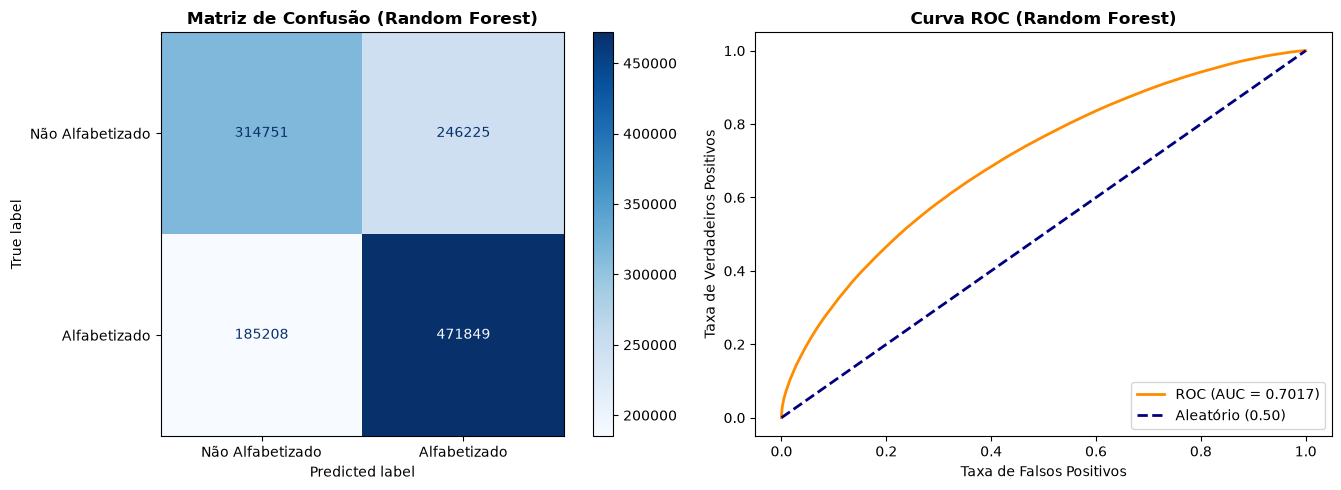

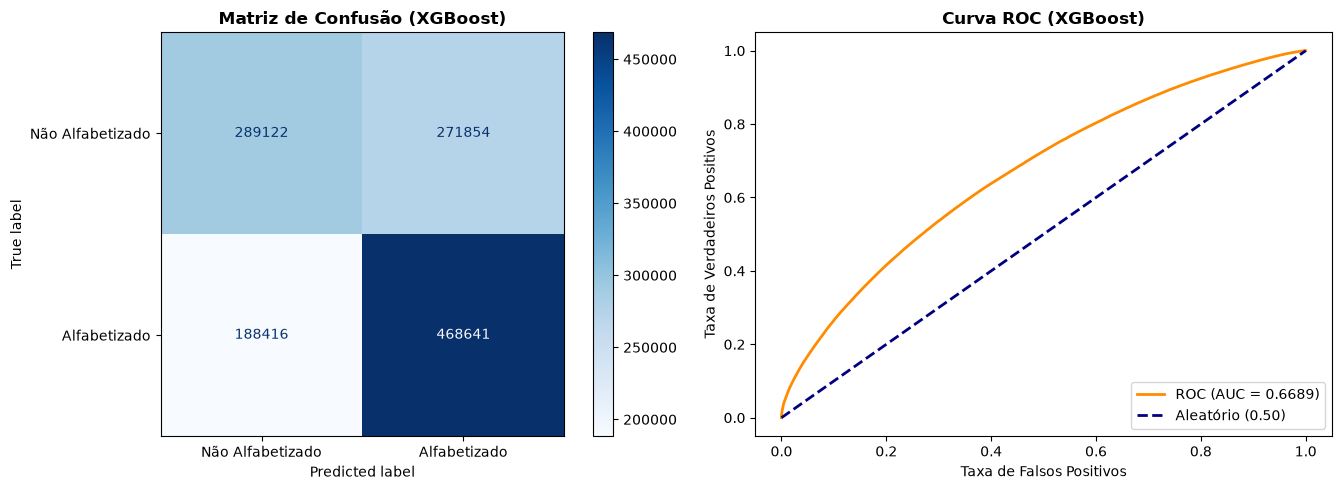

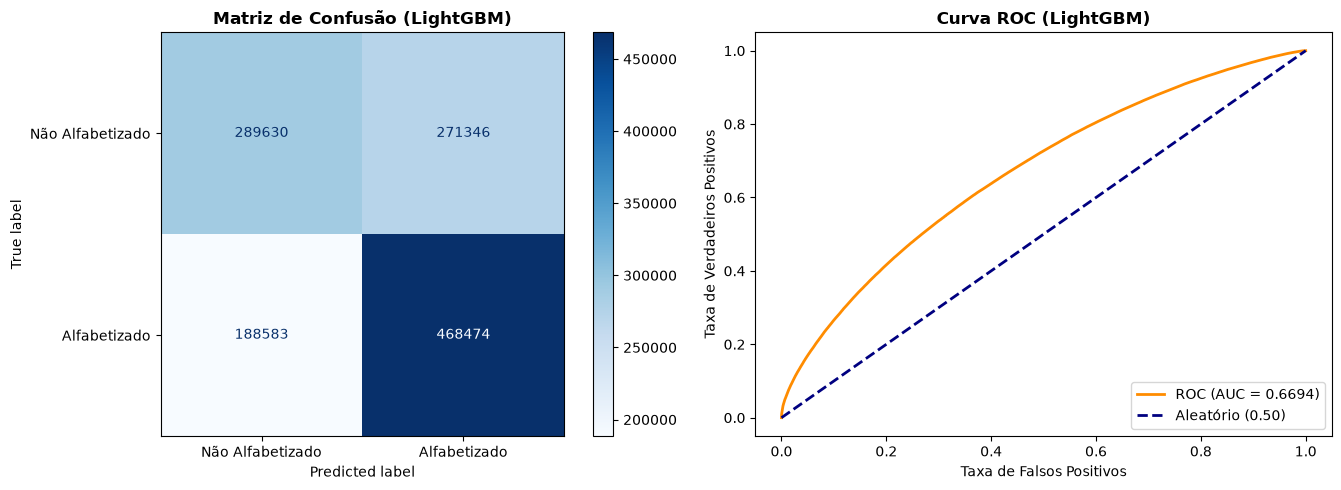

In [ ]:
plot_classificacao(rf, X_test, y_test, model_name="Random Forest")

plot_classificacao(xgb, X_test, y_test, model_name="XGBoost")

plot_classificacao(lgbm, X_test, y_test, model_name="LightGBM")

In [26]:
import joblib
import os

# 1. Garante que a pasta models existe
os.makedirs("models", exist_ok=True)

# 2. Salva o modelo treinado
caminho_local = "models/melhor_modelo_random_forest.joblib"
joblib.dump(rf, caminho_local)

tamanho_mb = os.path.getsize(caminho_local) / (1024 * 1024)
print(f"Modelo Random Forest salvo com sucesso em: {caminho_local} ({tamanho_mb:.2f} MB)")

#SALVAR NO S3 
caminho_s3 = "models/melhor_modelo_random_forest.joblib"

# Faz o upload do arquivo salvo para o bucket
s3.upload_file(caminho_local, BUCKET, caminho_s3)
print(f" Modelo enviado com sucesso para s3://{BUCKET}/{caminho_s3}!")


# import joblib

# # Carrega o modelo treinado instantaneamente (sem precisar treinar de novo)
# modelo_carregado = joblib.load("models/melhor_modelo_random_forest.joblib")

# # Faz previsões com ele:
# novas_previsoes = modelo_carregado.predict(X_test)
# print("Previsões geradas com sucesso!")



Modelo Random Forest salvo com sucesso em: models/melhor_modelo_random_forest.joblib (1059.38 MB)
 Modelo enviado com sucesso para s3://postech-challenge-datascience-003/models/melhor_modelo_random_forest.joblib!
